In [1]:
import pandas as pd
from datasets import load_from_disk,concatenate_datasets
from collections import Counter
from transformers import AutoTokenizer

/home/students/tborsani/NLBSE2026/myenv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
ds = load_from_disk("../data/augmented_datasets")

In [3]:
ds["java_train"][1263]

{'index': 4551,
 'class': 'VisualizerCPU.java',
 'comment_sentence': '\t/** Dispose method */',
 'partition': 0,
 'combo': '\t/** Dispose method */ | VisualizerCPU.java',
 'labels': [1, 0, 0, 0, 0, 0, 0],
 'similarity_score': 1.0,
 'synthetic': False}

In [4]:
langs = ['java', 'python', 'pharo']
labels = {
    'java': ['summary', 'Ownership', 'Expand', 'usage', 'Pointer', 'deprecation', 'rational'],
    'python': ['Usage', 'Parameters', 'DevelopmentNotes', 'Expand', 'Summary'],
    'pharo': ['Keyimplementationpoints', 'Example', 'Responsibilities', 'Intent', 'Keymessages', 'Collaborators']
}
def split_list_into_columns(row, lang):
    values_list = row['labels']  # Replace 'values' with your actual column name
    dict = {}
    for key in labels[lang]:
        
        dict[key] = values_list[labels[lang].index(key)]

    return dict


java = concatenate_datasets([ds["java_train"]]).map(lambda row: split_list_into_columns(row, "java"))
python = concatenate_datasets([ds["python_train"]]).map(lambda row: split_list_into_columns(row, "python"))
pharo = concatenate_datasets([ds["pharo_train"]]).map(lambda row: split_list_into_columns(row, "pharo"))


Map: 100%|██████████| 1799/1799 [00:00<00:00, 9947.22 examples/s] 


In [5]:
def print_labels(data, lang):
    for label in labels[lang]:
        group = Counter(data[label])
        synt = Counter(data["synthetic"])
        print(group,synt)
        print("label " + label)
        print("positive", group[1], ",negative", group[0], "--- %", (group[1]/(group[1]+group[0]))*100)
        print("number of augments | 10%", (group[0]-group[1])*0.1,
              "| 25%", (group[0]-group[1])*0.25,
              "| 50%", (group[0]-group[1])*0.5,
              "| 75%", (group[0]-group[1])*0.75,
              "| 100%", (group[0]-group[1]))
        print('*'*40)

from collections import Counter, defaultdict

def print_labels_and_synthetic(data, lang):
    for label in labels[lang]:
        # 2x2 counters
        counts = {
            "synthetic_pos": 0,
            "synthetic_neg": 0,
            "real_pos": 0,
            "real_neg": 0,
        }
        

        for d in data:
          
            if d["synthetic"]:
                if d[label] == 1:
                    counts["synthetic_pos"] += 1
                else:
                    counts["synthetic_neg"] += 1
            else:
                if d[label] == 1:
                    counts["real_pos"] += 1
                else:
                    counts["real_neg"] += 1

        total_pos = counts["synthetic_pos"] + counts["real_pos"]
        total_neg = counts["synthetic_neg"] + counts["real_neg"]
        total = total_pos + total_neg

        print("label", label)
        print("positives:", total_pos, "| negatives:", total_neg,
              "| % positives:", (total_pos / total * 100) if total > 0 else 0)

        print("synthetic positives:", counts["synthetic_pos"],
              "| synthetic negatives:", counts["synthetic_neg"])
        print("real positives:", counts["real_pos"],
              "| real negatives:", counts["real_neg"])

        print("*" * 40)


In [6]:
print_labels_and_synthetic(java, "java")

label summary
positives: 5069 | negatives: 5716 | % positives: 47.00046360686138
synthetic positives: 2534 | synthetic negatives: 2857
real positives: 2535 | real negatives: 2859
****************************************
label Ownership
positives: 376 | negatives: 10409 | % positives: 3.4863235975892444
synthetic positives: 188 | synthetic negatives: 5203
real positives: 188 | real negatives: 5206
****************************************
label Expand
positives: 754 | negatives: 10031 | % positives: 6.991191469633751
synthetic positives: 377 | synthetic negatives: 5014
real positives: 377 | real negatives: 5017
****************************************
label usage
positives: 3029 | negatives: 7756 | % positives: 28.085303662494205
synthetic positives: 1514 | synthetic negatives: 3877
real positives: 1515 | real negatives: 3879
****************************************
label Pointer
positives: 1349 | negatives: 9436 | % positives: 12.508113120074176
synthetic positives: 674 | synthetic nega

In [7]:
print_labels_and_synthetic(python, "python")

label Usage
positives: 862 | negatives: 1874 | % positives: 31.505847953216374
synthetic positives: 431 | synthetic negatives: 937
real positives: 431 | real negatives: 937
****************************************
label Parameters
positives: 804 | negatives: 1932 | % positives: 29.385964912280706
synthetic positives: 402 | synthetic negatives: 966
real positives: 402 | real negatives: 966
****************************************
label DevelopmentNotes
positives: 334 | negatives: 2402 | % positives: 12.207602339181287
synthetic positives: 167 | synthetic negatives: 1201
real positives: 167 | real negatives: 1201
****************************************
label Expand
positives: 558 | negatives: 2178 | % positives: 20.394736842105264
synthetic positives: 279 | synthetic negatives: 1089
real positives: 279 | real negatives: 1089
****************************************
label Summary
positives: 510 | negatives: 2226 | % positives: 18.640350877192983
synthetic positives: 255 | synthetic negat

In [8]:
print_labels_and_synthetic(pharo, "pharo")

label Keyimplementationpoints
positives: 252 | negatives: 1547 | % positives: 14.007782101167315
synthetic positives: 126 | synthetic negatives: 773
real positives: 126 | real negatives: 774
****************************************
label Example
positives: 747 | negatives: 1052 | % positives: 41.5230683713174
synthetic positives: 373 | synthetic negatives: 526
real positives: 374 | real negatives: 526
****************************************
label Responsibilities
positives: 360 | negatives: 1439 | % positives: 20.01111728738188
synthetic positives: 180 | synthetic negatives: 719
real positives: 180 | real negatives: 720
****************************************
label Intent
positives: 234 | negatives: 1565 | % positives: 13.007226236798223
synthetic positives: 117 | synthetic negatives: 782
real positives: 117 | real negatives: 783
****************************************
label Keymessages
positives: 326 | negatives: 1473 | % positives: 18.12117843246248
synthetic positives: 163 | synt

In [9]:
import pandas as pd
from tqdm import tqdm
import numpy as np

data = pd.concat([ds["java_train"].to_pandas(), ds["python_train"].to_pandas(), ds["pharo_train"].to_pandas()])
data["len_tokens"] = None
data["sumLabel"] = None

len(data)
tokenizer = AutoTokenizer.from_pretrained("roberta-base")

pbar = tqdm(total=len(data), desc="adding tokens length...")

for index, row in data.iterrows():
    input = row["combo"]
    tokens = tokenizer.encode(input)
    len_tokens = len(tokens)
    data.loc[index, "len_tokens"] = len_tokens
    data.loc[index, "sumLabel"] = sum(row["labels"])
    pbar.update(1)

pbar.close()

data

adding tokens length...: 100%|██████████| 15320/15320 [00:04<00:00, 3456.99it/s]


,index,class,comment_sentence,partition,combo,labels,similarity_score,synthetic,len_tokens,sumLabel
0,1,Abfss.java,this impl delegates to the old filesystem,0,this impl delegates to the old filesystem | Ab...,"[0, 0, 1, 0, 0, 0, 0]",1.000000,False,31,1
1,2,AbstractContractGetFileStatusTest.java,test getfilestatus and related listing operati...,0,test getfilestatus and related listing operati...,"[1, 0, 0, 0, 0, 0, 0]",1.000000,False,19,1
2,15,AbstractContractGetFileStatusTest.java,a filesystem filter which exposes the protecte...,0,a filesystem filter which exposes the protecte...,"[0, 0, 1, 0, 0, 0, 0]",1.000000,False,22,1
3,16,AbstractContractGetFileStatusTest.java,"@link #listlocatedstatus path, pathfilter .",0,"@link #listlocatedstatus path, pathfilter . | ...","[0, 0, 1, 0, 0, 0, 0]",1.000000,False,40,1
4,18,ApplicationConstants.java,the type of launch for the container.,0,the type of launch for the container. | Applic...,"[0, 0, 1, 0, 0, 0, 0]",1.000000,False,16,1
...,...,...,...,...,...,...,...,...,...,...
1794,1836,WATagBrush,attributes instance of wahtmlattributes,0,attributes instance of wahtmlattributes | WHTa...,"[1, 0, 0, 0, 0, 0]",0.905083,True,17,1
1795,1838,WAUpTimeTracker,wauptimetracker is used to track the timestamp...,0,wauptimetracker is used to track the timestamp...,"[0, 0, 1, 0, 0, 0]",0.994598,True,25,1
1796,1839,WAUpTimeTracker,access the timestamp when the image booted as ...,0,access the timestamp when the image booted as ...,"[0, 0, 1, 0, 1, 1]",0.963787,True,16,3
1797,1842,WAUpTimeTracker,access the duration how long ago the image boo...,0,access the duration how long ago the image boo...,"[0, 0, 1, 0, 1, 1]",0.994821,True,18,3


Min: 5
Max: 526
Average: 24.40
Median: 20.00


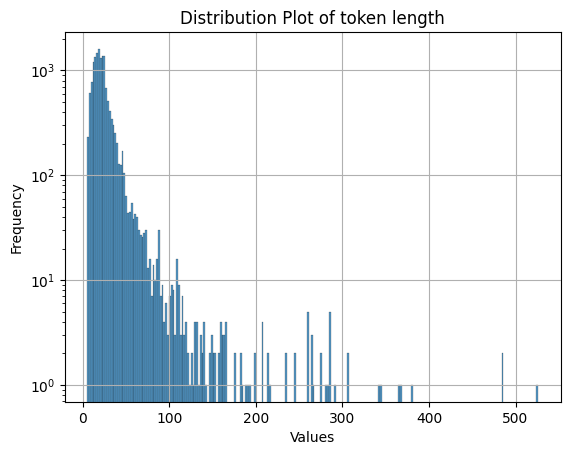

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
list_token_length = data['len_tokens']
min_value = np.min(list_token_length)
max_value = np.max(list_token_length)
average = np.mean(list_token_length)
median = np.median(list_token_length)

print(f"Min: {min_value}")
print(f"Max: {max_value}") # apparently, one single input is longer than 512 and is truncated - I dont see an issue there
print(f"Average: {average:.2f}")
print(f"Median: {median:.2f}")

sns.histplot(list_token_length, kde=False)
plt.title("Distribution Plot of token length")
plt.yscale('log') # Adding a log scale at the y-axis to give more visibility to the long inputs
plt.xlabel("Values")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()

Token indices sequence length is longer than the specified maximum sequence length for this model (526 > 512). Running this sequence through the model will result in indexing errors



 Java dataset:
Min: 7
Max: 526
Average: 28.47
Median: 22.00


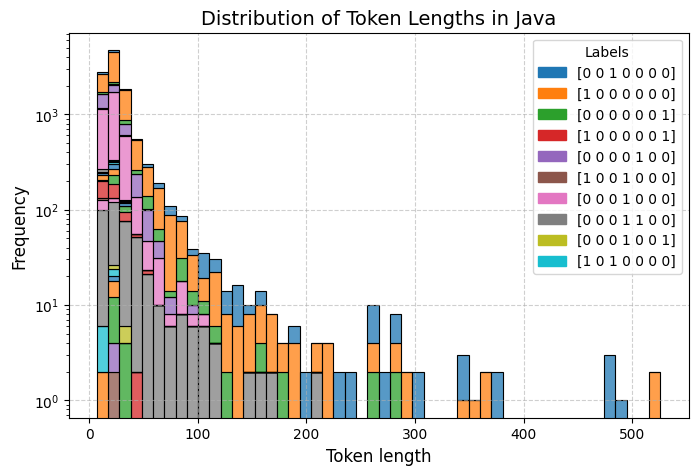


 Python dataset:
Min: 5
Max: 45
Average: 15.01
Median: 15.00


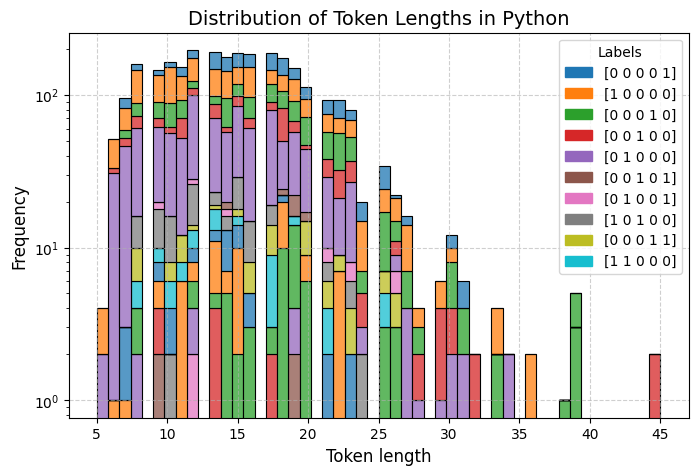


 Pharo dataset:
Min: 6
Max: 104
Average: 20.51
Median: 19.00


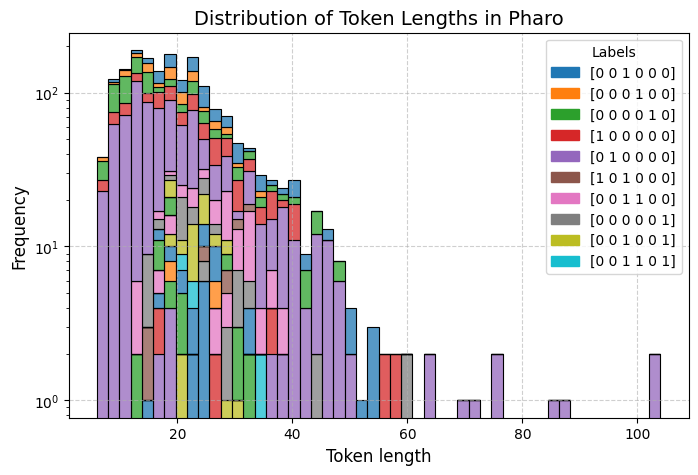

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch

tokenizer = AutoTokenizer.from_pretrained("roberta-base")

datasets = {
    "Java": ds["java_train"].to_pandas(),
    "Python": ds["python_train"].to_pandas(),
    "Pharo": ds["pharo_train"].to_pandas(),
}

for lang, df in datasets.items():
    # Compute token length and sum of labels
    df["len_tokens"] = df["combo"].apply(lambda x: len(tokenizer.encode(x)))
    df["sumLabel"] = df["labels"].apply(sum)
    df['hue']=df["labels"].apply(str)

    # Stats
    min_value = df["len_tokens"].min()
    max_value = df["len_tokens"].max()
    avg_value = df["len_tokens"].mean()
    median_value = df["len_tokens"].median()

    print(f"\n {lang} dataset:")
    print(f"Min: {min_value}")
    print(f"Max: {max_value}")
    print(f"Average: {avg_value:.2f}")
    print(f"Median: {median_value:.2f}")

    # Plot distribution colored by label count
    plt.figure(figsize=(8, 5))
    sns.histplot(data=df, x="len_tokens", hue="hue", bins=50, kde=False, multiple="stack",
    palette="tab10",
    legend=True)
    plt.title(f"Distribution of Token Lengths in {lang}", fontsize=14)
    plt.yscale('log')  # better visibility
    plt.xlabel("Token length", fontsize=12)
    plt.ylabel("Frequency", fontsize=12)
    handles = [Patch(color=c, label=l) for l, c in zip(df["hue"].unique(), sns.color_palette("tab10"))]
    plt.legend(handles=handles, title="Labels", loc="upper right")
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.show()


Token indices sequence length is longer than the specified maximum sequence length for this model (526 > 512). Running this sequence through the model will result in indexing errors


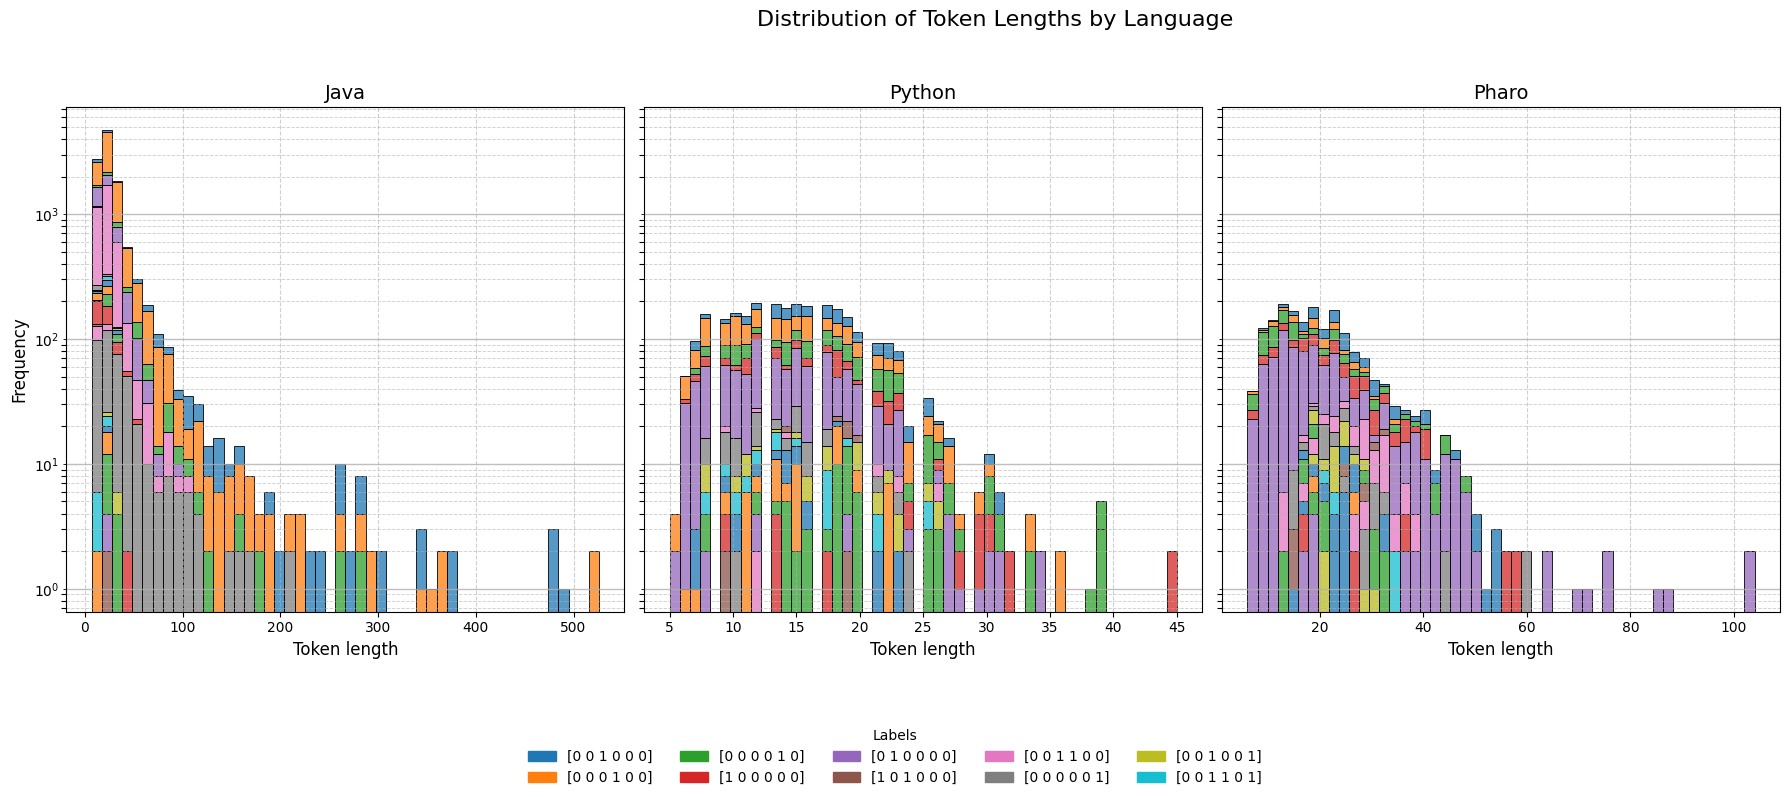

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch
from matplotlib.ticker import LogLocator
tokenizer = AutoTokenizer.from_pretrained("roberta-base")

datasets = {
    "Java": ds["java_train"].to_pandas(),
    "Python": ds["python_train"].to_pandas(),
    "Pharo": ds["pharo_train"].to_pandas(),
}

fig, axes = plt.subplots(1, len(datasets), figsize=(20, 8), sharey=True)

for ax, (lang, df) in zip(axes, datasets.items()):
    # Compute token length and sum of labels
    df["len_tokens"] = df["combo"].apply(lambda x: len(tokenizer.encode(x)))
    df["sumLabel"] = df["labels"].apply(sum)
    df["hue"] = df["labels"].apply(str)

    # Stats
    min_value = df["len_tokens"].min()
    max_value = df["len_tokens"].max()
    avg_value = df["len_tokens"].mean()
    median_value = df["len_tokens"].median()


    # Plot on subplot
    sns.histplot(
        data=df,
        x="len_tokens",
        hue="hue",
        bins=50,
        kde=False,
        multiple="stack",
        palette="tab10",
        legend=False,
        ax=ax,
    )
    ax.set_title(f"{lang}", fontsize=14)
    ax.set_yscale("log")
    # Major ticks: powers of 10
    ax.yaxis.set_major_locator(LogLocator(base=10.0, subs=None, numticks=10))
    ax.grid(which="major", axis="y", linestyle="--", linewidth=0.65, alpha=0.65)

    # Minor ticks: between powers of 10
    ax.yaxis.set_minor_locator(LogLocator(base=10.0, subs=range(1, 10), numticks=10))
    ax.grid(which="minor", axis="y", linestyle="-", linewidth=1, alpha=0.8)
    ax.set_xlabel("Token length", fontsize=12)
    ax.set_ylabel("Frequency", fontsize=12 if ax == axes[0] else 0)
    ax.grid(True, linestyle="--", alpha=0.6)

# Shared legend
handles = [Patch(color=c, label=l) for l, c in zip(df["hue"].unique(), sns.color_palette("tab10"))]
fig.legend(handles=handles, title="Labels", loc="lower center",
    ncol=5,   # max per row
    frameon=False,)

fig.suptitle("Distribution of Token Lengths by Language", fontsize=16)
plt.tight_layout(rect=[0, 0.15, 0.9, 0.95])
plt.show()


Token indices sequence length is longer than the specified maximum sequence length for this model (526 > 512). Running this sequence through the model will result in indexing errors


Java: 0 observations with all-zero labels
Python: 0 observations with all-zero labels
Pharo: 0 observations with all-zero labels


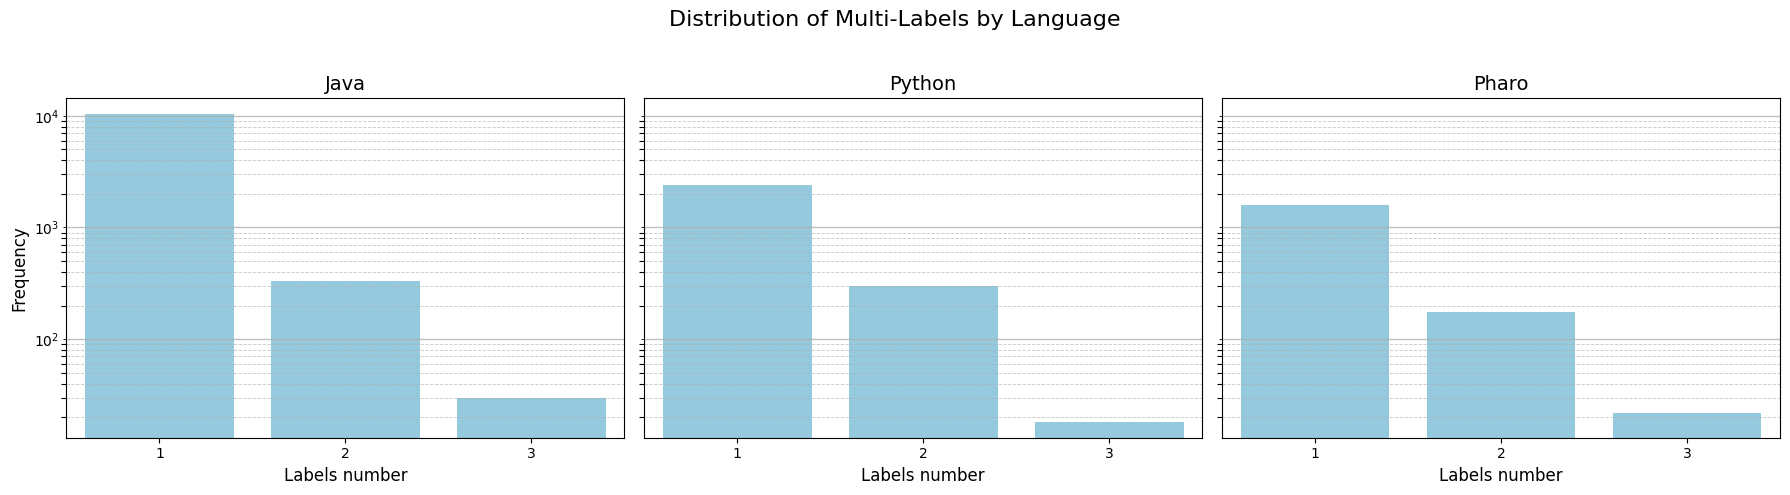

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.ticker import LogLocator

tokenizer = AutoTokenizer.from_pretrained("roberta-base")

datasets = {
    "Java": ds["java_train"].to_pandas(),
    "Python": ds["python_train"].to_pandas(),
    "Pharo": ds["pharo_train"].to_pandas(),
}

fig, axes = plt.subplots(1, len(datasets), figsize=(18, 5), sharey=True)

for ax, (lang, df) in zip(axes, datasets.items()):
    # Compute token length and sum of labels
    df["len_tokens"] = df["combo"].apply(lambda x: len(tokenizer.encode(x)))
    df["sumLabel"] = df["labels"].apply(sum)

    # Number of all-zero labels
    num_zero_labels = (df["sumLabel"] == 0).sum()
    print(f"{lang}: {num_zero_labels} observations with all-zero labels")

    # Frequency of each label count
    length_counts = df["sumLabel"].value_counts().sort_index()

    # Plot as bar chart
    sns.barplot(
        x=length_counts.index,
        y=length_counts.values,
        color="skyblue",
        ax=ax
    )

    ax.set_title(f"{lang}", fontsize=14)
    ax.set_xlabel("Labels number", fontsize=12)
    ax.set_ylabel("Frequency", fontsize=12 if ax == axes[0] else 0)
    ax.set_yscale("log")

    # Major ticks: powers of 10
    ax.yaxis.set_major_locator(LogLocator(base=10.0, subs=None, numticks=10))
    ax.grid(which="major", axis="y", linestyle="--", linewidth=0.65, alpha=0.65)

    # Minor ticks: between powers of 10
    ax.yaxis.set_minor_locator(LogLocator(base=10.0, subs=range(1, 10), numticks=10))
    ax.grid(which="minor", axis="y", linestyle="-", linewidth=1, alpha=0.8)

fig.suptitle("Distribution of Multi-Labels by Language", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


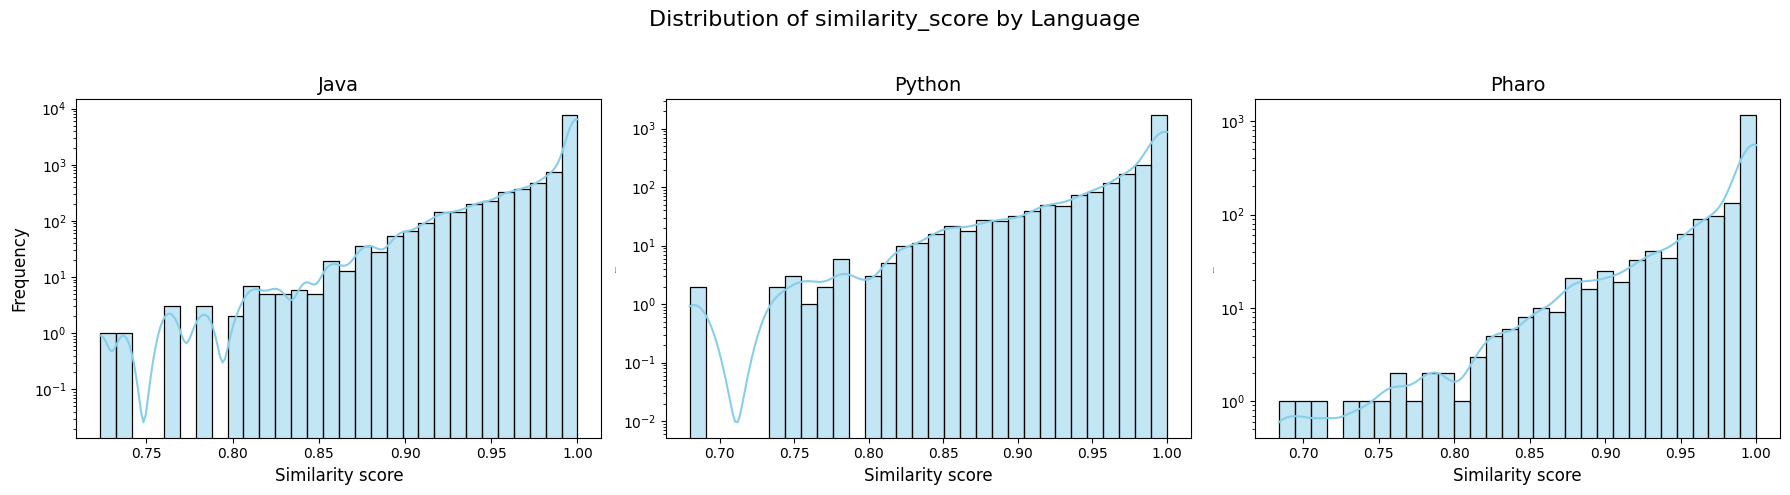

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, len(datasets), figsize=(18, 5), sharey=False)

for ax, (lang, df) in zip(axes, datasets.items()):
    sns.histplot(
        df["similarity_score"],
        bins=30,
        kde=True,
        color="skyblue",
        ax=ax
    )

    ax.set_title(f"{lang}", fontsize=14)
    ax.set_xlabel("Similarity score", fontsize=12)
    ax.set_ylabel("Frequency", fontsize=12 if ax == axes[0] else 0)

    ax.set_yscale("log")
fig.suptitle("Distribution of similarity_score by Language", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

In [15]:
def generate_weights(weighted_loss, data):

    if weighted_loss == "frequency":
        labels = data["labels"]
        labels_array = np.array(labels)
        class_counts = labels_array.sum(axis=0)
        total_samples = len(labels)
        class_frequencies = (class_counts/total_samples)*100
        result = []

        for i, freq in enumerate(class_frequencies):
            result.append(round(1/freq, 2))

        result = np.array(result)

        return class_frequencies #* (1 / np.sum(result))

    if weighted_loss == "ranked":
        labels = data["labels"]
        labels_array = np.array(labels)
        class_counts = labels_array.sum(axis=0)
        total_samples = len(labels)
        class_frequencies = (class_counts/total_samples)*100

        sorted_values = sorted(range(len(class_frequencies)), key=lambda x: class_frequencies[x], reverse=True)
        sorted_frequencies = sorted(class_frequencies)

        mapped_output = [0] * len(class_frequencies)
        for i, idx in enumerate(sorted_values):
            mapped_output[idx] = sorted_frequencies[i]

        return mapped_output


    # NO WEIGHTED LOSS
    return [1] * len(data[0]["labels"])

In [16]:
print(f"frequency: {generate_weights('frequency', ds['java_train'])}")
print(f"ranked: {generate_weights('ranked', ds['java_train'])}")
print(f"noweight: {generate_weights('no', ds['java_train'])}")

frequency: [47.00046361  3.4863236   6.99119147 28.08530366 12.50811312  1.48354196
  4.09828465]
ranked: [np.float64(1.4835419564209549), np.float64(28.085303662494205), np.float64(6.991191469633751), np.float64(3.4863235975892444), np.float64(4.098284654612888), np.float64(47.00046360686138), np.float64(12.508113120074176)]
noweight: [1, 1, 1, 1, 1, 1, 1]
